In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')  

In [23]:
print(df.head())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [24]:
# Encoding categorical variables
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])  # Male=1, Female=0
df['Membership Type'] = encoder.fit_transform(df['Membership Type'])  # Gold=2, Silver=1, Bronze=0
df['Satisfaction Level'] = encoder.fit_transform(df['Satisfaction Level'])  # Satisfied=2, Neutral=1, Unsatisfied=0

# Convert 'Discount Applied' to numeric (True=1, False=0)
df['Discount Applied'] = df['Discount Applied'].astype(int)


In [25]:
# Scaling numerical features
scaler = StandardScaler()
numeric_features = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [26]:
print("Preprocessing complete!")

Preprocessing complete!


C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


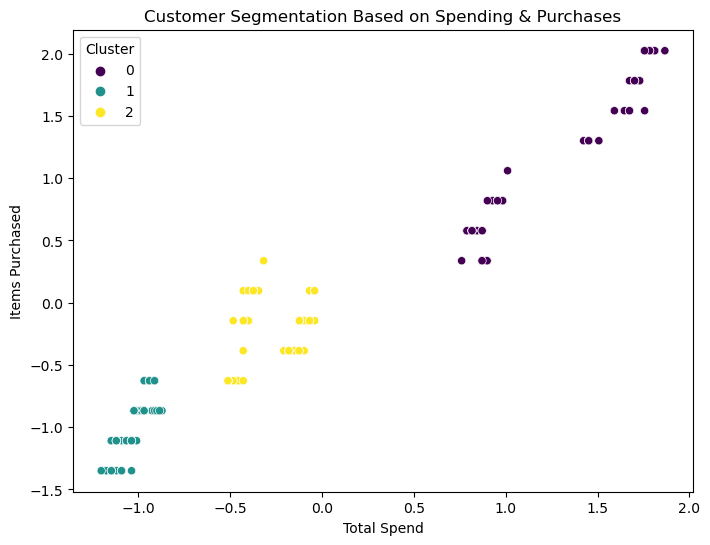

In [27]:
# Selecting features for clustering
X = df[['Total Spend', 'Items Purchased', 'Age', 'Membership Type']]

# Applying K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualizing clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Total Spend'], y=df['Items Purchased'], hue=df['Cluster'], palette='viridis')
plt.title('Customer Segmentation Based on Spending & Purchases')
plt.xlabel('Total Spend')
plt.ylabel('Items Purchased')
plt.show()


Accuracy: 0.9428571428571428
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.90        23
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00        18
           3       0.00      0.00      0.00         0

    accuracy                           0.94        70
   macro avg       0.75      0.71      0.73        70
weighted avg       1.00      0.94      0.97        70



C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 14.722222222222216, 'Predicted')

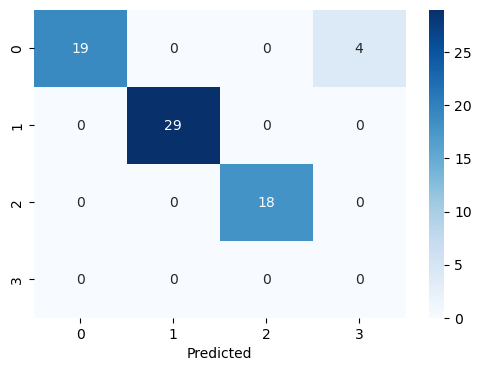

In [49]:
# Splitting dataset for training & testing
X = df[['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Membership Type', 'Discount Applied', 'Days Since Last Purchase']]
y = df['Satisfaction Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying Random Forest Classifier
model = RandomForestClassifier(n_estimators=50, max_depth=20, class_weight='balanced',random_state=42)
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualizing Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')# Splitting dataset for training & testing

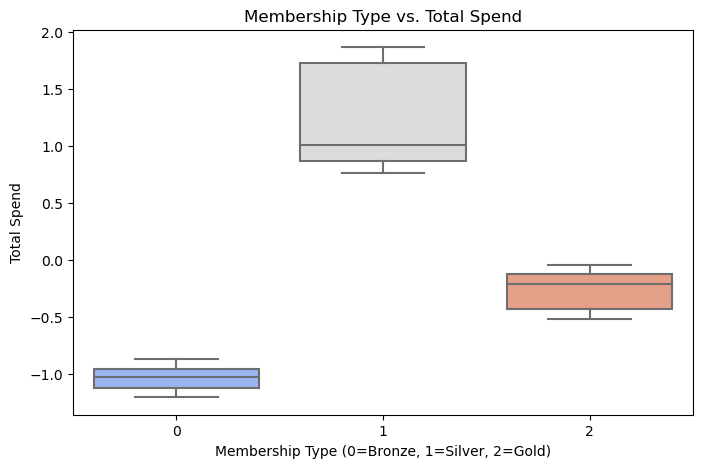

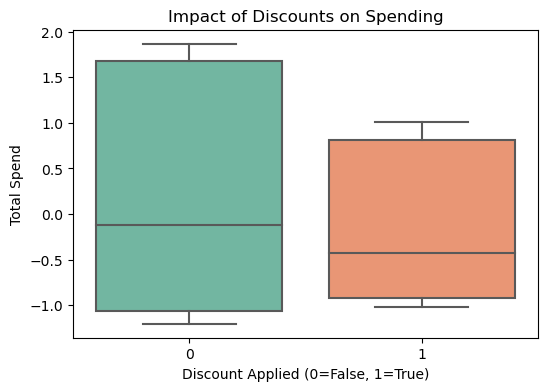

In [38]:
# Analyzing Membership Impact on Spending
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Membership Type'], y=df['Total Spend'], palette='coolwarm')
plt.title('Membership Type vs. Total Spend')
plt.xlabel('Membership Type (0=Bronze, 1=Silver, 2=Gold)')
plt.ylabel('Total Spend')
plt.show()

# Discount Influence on Customer Behavior
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Discount Applied'], y=df['Total Spend'], palette='Set2')
plt.title('Impact of Discounts on Spending')
plt.xlabel('Discount Applied (0=False, 1=True)')
plt.ylabel('Total Spend')
plt.show()


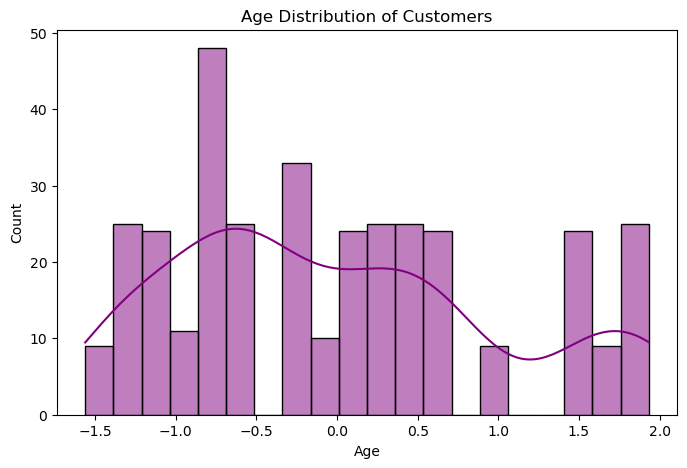

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='purple')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


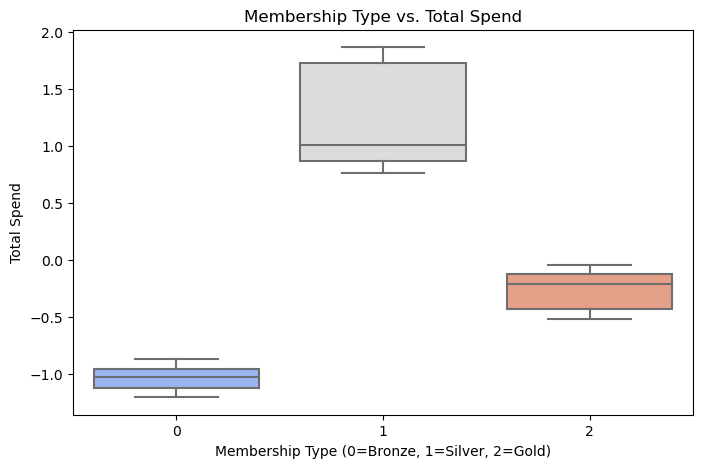

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Membership Type'], y=df['Total Spend'], palette='coolwarm')
plt.title('Membership Type vs. Total Spend')
plt.xlabel('Membership Type (0=Bronze, 1=Silver, 2=Gold)')
plt.ylabel('Total Spend')
plt.show()


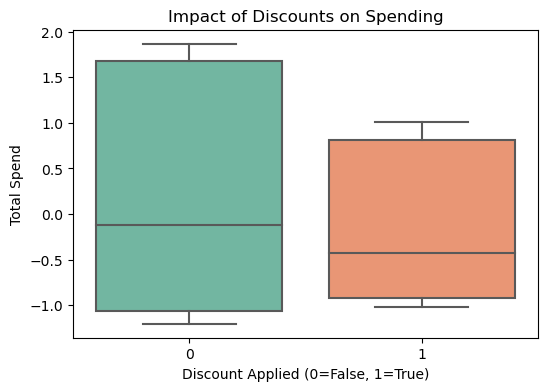

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Discount Applied'], y=df['Total Spend'], palette='Set2')
plt.title('Impact of Discounts on Spending')
plt.xlabel('Discount Applied (0=False, 1=True)')
plt.ylabel('Total Spend')
plt.show()


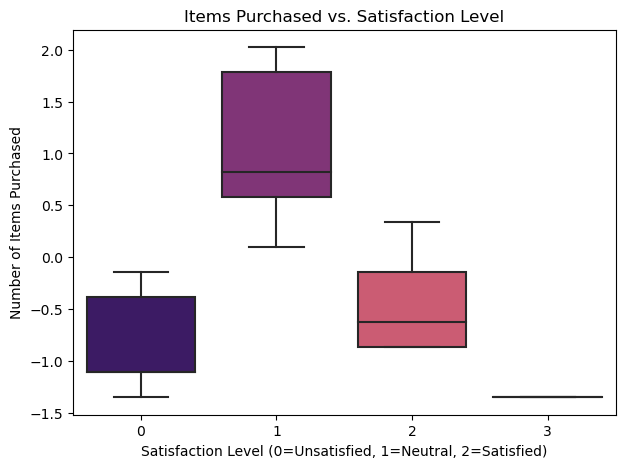

In [42]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['Satisfaction Level'], y=df['Items Purchased'], palette='magma')
plt.title('Items Purchased vs. Satisfaction Level')
plt.xlabel('Satisfaction Level (0=Unsatisfied, 1=Neutral, 2=Satisfied)')
plt.ylabel('Number of Items Purchased')
plt.show()


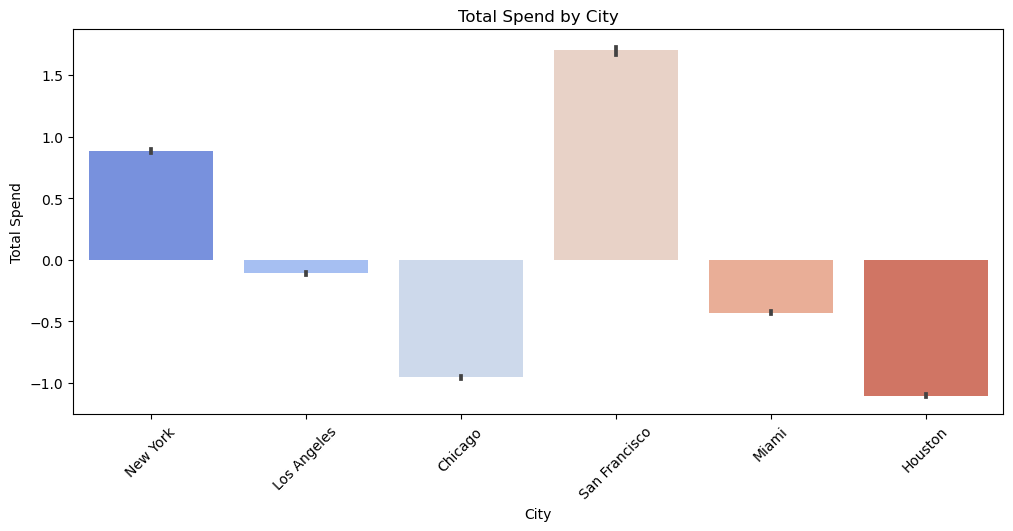

In [43]:
plt.figure(figsize=(12,5))
sns.barplot(x=df['City'], y=df['Total Spend'], palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Total Spend by City')
plt.xlabel('City')
plt.ylabel('Total Spend')
plt.show()


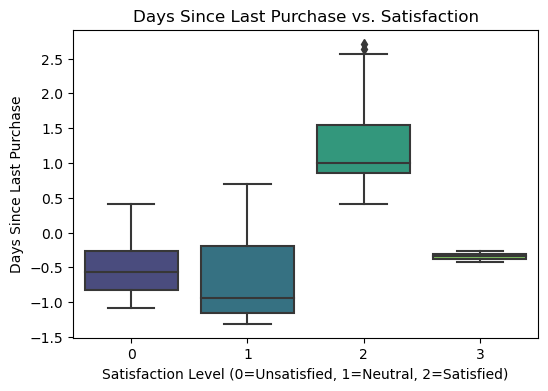

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Satisfaction Level'], y=df['Days Since Last Purchase'], palette='viridis')
plt.title('Days Since Last Purchase vs. Satisfaction')
plt.xlabel('Satisfaction Level (0=Unsatisfied, 1=Neutral, 2=Satisfied)')
plt.ylabel('Days Since Last Purchase')
plt.show()


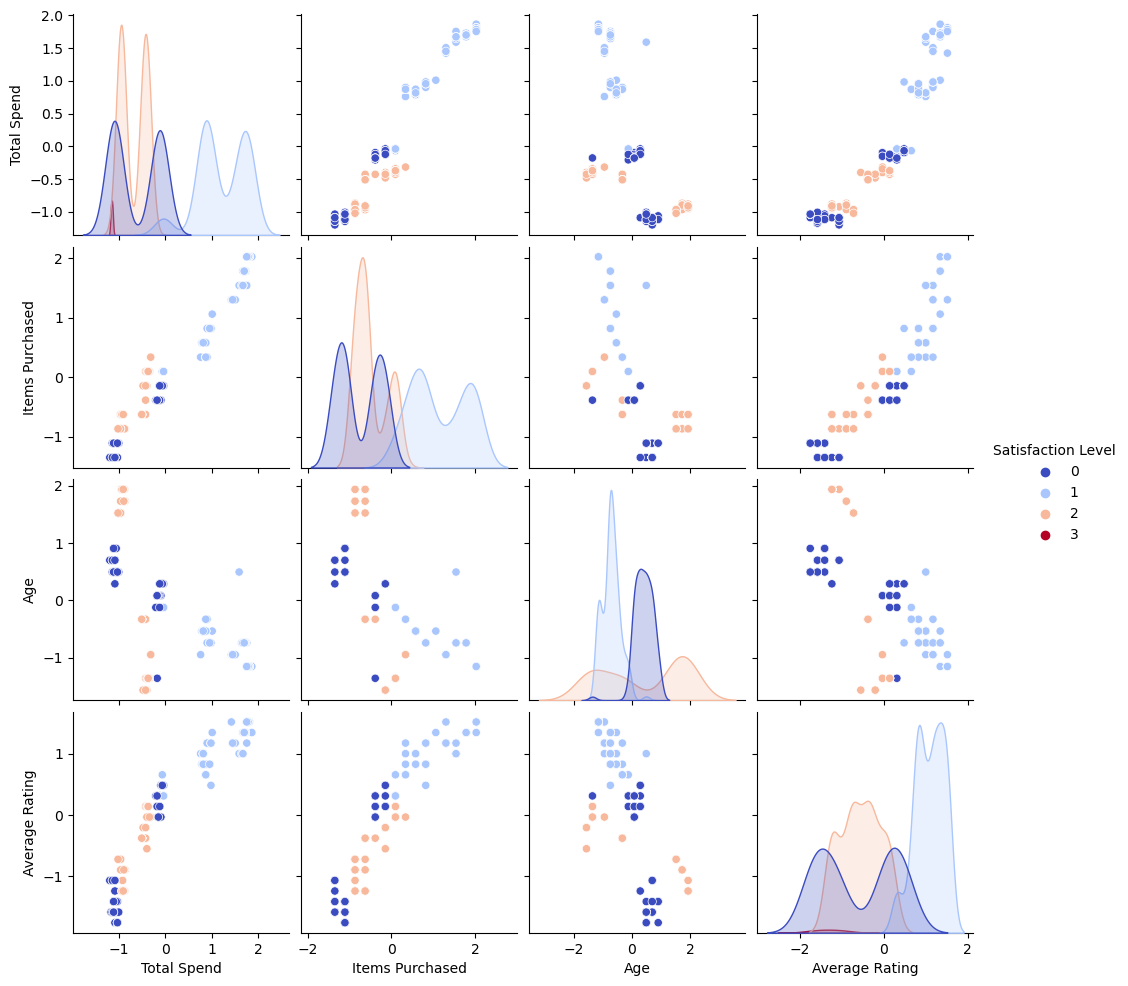

In [45]:
sns.pairplot(df[['Total Spend', 'Items Purchased', 'Age', 'Average Rating', 'Satisfaction Level']], hue='Satisfaction Level', palette='coolwarm')
plt.show()


C:\Users\SAI LAKSHMI BHAVYA\AppData\Local\Temp\ipykernel_23852\3277016657.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")


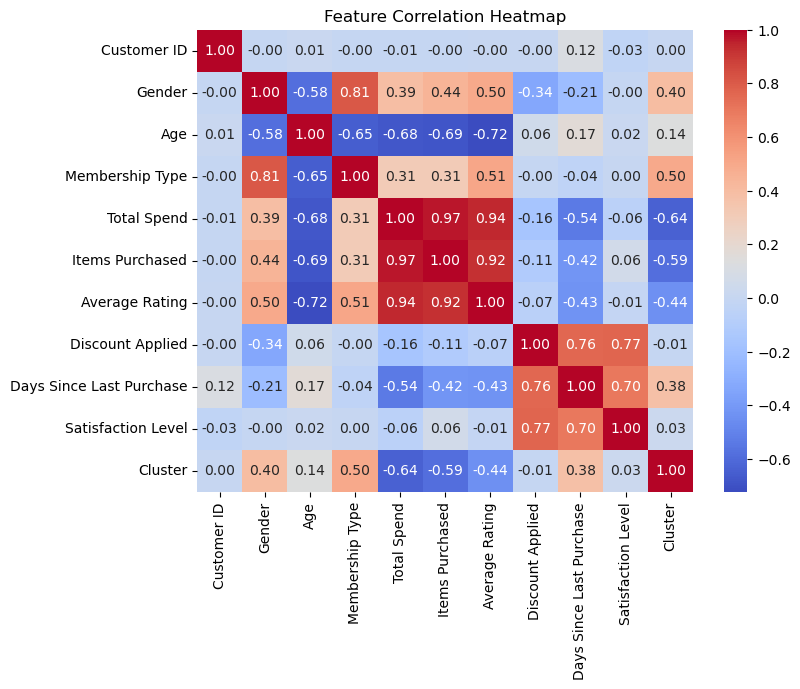

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()
